Simple Linear Regression


   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891
Intercept (β₀): 25321.58
Slope (β₁): 9423.82
R² Score: 0.90


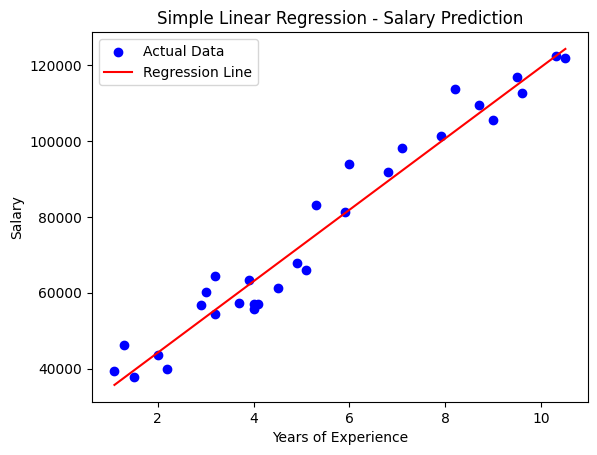

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Data Load karo
#CSV file ko load kiya aur first 5 rows dekhi
df = pd.read_csv('salary_data.csv')
print(df.head())

# 2. X aur Y alag karo
# X (input) = experience
# y (output) = salary
#  Matlab: experience se salary predict karni hai
X = df[['YearsExperience']]
y = df['Salary']

# 3. Train/Test split karo
# 80% data → training
# 20% data → testing

# Taake model fair tarike se check ho
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model banao
# Transform tab use hota hai jab hum data ko change/scale/encode karte hain.(Transform is not the attribute of linear regression ,so we can't do the transform in linear regression)
# Examples:
# StandardScaler
# MinMaxScaler
# OneHotEncoder
model = LinearRegression()
# Model ne data se line learn ki (best fit line)
model.fit(X_train, y_train)

# 5. Predict karo
# Model ne new data ke liye salary predict ki
y_pred = model.predict(X_test)

# 6. Results dekho
# R² agar 1 ke close ho → model acha hai
print(f"Intercept (β₀): {model.intercept_:.2f}")
print(f"Slope (β₁): {model.coef_[0]:.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")

# 7. Plot karo
# Blue dots → real data
# Red line → model ki prediction
# Is se hum dekhte hain model kitna fit hai
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Simple Linear Regression - Salary Prediction')
plt.legend()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ============================================
# 1. DATA LOAD KARO
# ============================================
df = pd.read_csv('salary_data.csv')
print("=" * 45)  #Screen par line print karta hai formatting ke liye
print("        SALARY PREDICTION SYSTEM        ")
print("=" * 45)  #Dataset ki first 5 rows show karta hai
print("\n📊 Dataset ki pehli 5 rows:")
print(df.head())
print(f"\nTotal Records: {df.shape[0]}")    #Total rows (records) count karta hai
# Dataset load kiya aur:
# first 5 rows dekhi
# total records count kiya
# ============================================
# 2. X AUR Y ALAG KARO
# ============================================
X = df[['YearsExperience']]
y = df['Salary']
# X = input (experience)
# y = output (salary)
# ============================================
# 3. TRAIN / TEST SPLIT
# ============================================
# 80% training
# 20% testing
# Model ko train aur test dono karne ke liye
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n🔀 Training Data: {X_train.shape[0]} rows")  #Training rows count
print(f"🔀 Testing Data:  {X_test.shape[0]} rows")   #esting rows count

# ============================================
# 4. MODEL TRAIN KARO
# ============================================
# Transform tab use hota hai jab hum data ko change/scale/encode karte hain.(Transform is not the attribute of linear regression ,so we can't do the transform in linear regression)
# Examples:
# StandardScaler
# MinMaxScaler
# OneHotEncoder
model = LinearRegression()
model.fit(X_train, y_train) #Model ne training data se learn kiya (line find ki)

# ============================================
# 5. PREDICTIONS KARO
# ============================================
# Testing data ke liye salary predict ki
y_pred = model.predict(X_test)

# ============================================
# 6. ACCURACY / METRICS
# ============================================
# R² → jitna 1 ke close utna acha
# Errors → jitne kam utna acha
r2     = r2_score(y_test, y_pred)
mse    = mean_squared_error(y_test, y_pred)   #Squared error
rmse   = np.sqrt(mse)
mae    = mean_absolute_error(y_test, y_pred)   #Average error
accuracy_percent = r2 * 100   #Percentage me convert kiya

print("\n" + "=" * 45)
print("         📈 MODEL ACCURACY RESULTS        ")
print("=" * 45)
print(f"  ✅ R² Score       : {r2:.4f}")
print(f"  ✅ Accuracy       : {accuracy_percent:.2f}%")  #Percentage accuracy
print(f"  ✅ MAE  (Mean Abs Error)  : ${mae:,.2f}")
print(f"  ✅ MSE  (Mean Sq  Error)  : ${mse:,.2f}")
print(f"  ✅ RMSE (Root MSE)        : ${rmse:,.2f}")
print("=" * 45)
print(f"\n📌 Regression Line:")
print(f"   Salary = {model.intercept_:,.2f} + {model.coef_[0]:,.2f} × YearsExperience")

# ============================================
# 7. USER INPUT SE PREDICTION
# ============================================
print("\n" + "=" * 45)
print("       🔮 APNI SALARY PREDICT KARO       ")
print("=" * 45)

while True:  #Infinite loop (bar bar input lene ke liye)
    try:
        user_input = input("\nApne Years of Experience daalo (ya 'exit' likho band karne ke liye): ")
        
        if user_input.lower() == 'exit':  #Agar user "exit" likhe → program band
            print("\n✅ Program band ho gaya. Shukriya!")
            break
        
        years = float(user_input)
        
        if years < 0:  #Negative value check
            print("❌ Experience negative nahi ho sakta! Dobara daalo.")
            continue
        
        predicted_salary = model.predict([[years]])[0]  #User ke experience ke liye salary predict ki
        
        print(f"\n  🎯 {years} saal ke experience ke liye:")
        print(f"  💰 Predicted Salary = ${predicted_salary:,.2f}")
        
    except ValueError:
        print("❌ Galat input! Sirf number daalo (jaise: 3.5)")
# User apna experience dalega aur model:

# salary predict karega
# jab "exit" likhe → program band

# Validation bhi hai:

# negative value allowed nahi
# wrong input handle hota hai

# ============================================
# 8. GRAPH PLOT KARO
# ============================================
plt.figure(figsize=(10, 6))  #Graph ka size set kiya

# Scatter plot - actual data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.7, s=60) #Training data points
plt.scatter(X_test,  y_test,  color='green', label='Testing Data', alpha=0.7, s=60)  #Testing data points

# Regression line
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1) #Smooth line banane ke liye points generate kiye
y_line = model.predict(X_line) #Line ke values predict ki
plt.plot(X_line, y_line, color='red', linewidth=2, label='Regression Line')   #Regression line draw ki

# Labels & Title
plt.title(f'Simple Linear Regression - Salary Prediction\nAccuracy (R²): {accuracy_percent:.2f}%', fontsize=14) #Graph ka title
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('salary_regression_plot.png', dpi=150) #Graph file me save bhi ho jata hai
plt.show()  #Screen par show
print("\n📊 Graph 'salary_regression_plot.png' mein save ho gaya!")

        SALARY PREDICTION SYSTEM        

📊 Dataset ki pehli 5 rows:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891

Total Records: 30

🔀 Training Data: 24 rows
🔀 Testing Data:  6 rows

         📈 MODEL ACCURACY RESULTS        
  ✅ R² Score       : 0.9024
  ✅ Accuracy       : 90.24%
  ✅ MAE  (Mean Abs Error)  : $6,286.45
  ✅ MSE  (Mean Sq  Error)  : $49,830,096.86
  ✅ RMSE (Root MSE)        : $7,059.04

📌 Regression Line:
   Salary = 25,321.58 + 9,423.82 × YearsExperience

       🔮 APNI SALARY PREDICT KARO       
